# Direct Methods for Optimal Control

Indirect methods first derive necessary optimality conditions and then solve the resulting boundary-value problem.

Direct methods instead discretize the original optimal control problem and solve the resulting finite-dimensional constrained optimization problem.

In this notebook, we first use a double integrator to understand the transcription itself, then extend the same idea to a nonlinear 2D car model.

## 1. Double Integrator — Direct Transcription

### Requirement

Move the system from

$$
p(0)=0,\qquad v(0)=0
$$

to

$$
p(T)=1,\qquad v(T)=0
$$

while minimizing control effort.

### State

$$
x=
\begin{bmatrix}
p\\
v
\end{bmatrix}
$$

### Control

$$
u=a
$$

### Continuous dynamics

$$
\dot{x}=
f(x,u)=
\begin{bmatrix}
v\\
u
\end{bmatrix}
$$

### Objective

$$
J=
\frac12\int_0^T u(t)^2\,dt.
$$

## From Continuous OCP to Discrete Optimization

The original optimal control problem is defined in continuous time:

$$
\min_{x(t),u(t)}
\frac{1}{2}\int_0^T u(t)^2\,dt
$$

subject to

$$
\dot{x}(t)=f(x(t),u(t)).
$$

A numerical optimizer cannot directly optimize continuous functions
$x(t)$ and $u(t)$.  
The first step in a direct method is therefore to **discretize time**.

Choose

$$
t_0,t_1,\ldots,t_N,
\qquad
\Delta t = \frac{T}{N}.
$$

The continuous trajectories are represented by discrete values

$$
x_k \approx x(t_k),
\qquad
u_k \approx u(t_k).
$$

### Discretizing the dynamics

Using Forward Euler,

$$
\dot{x}(t)
\approx
\frac{x_{k+1}-x_k}{\Delta t}.
$$

Since

$$
\dot{x}=f(x,u),
$$

we obtain

$$
\frac{x_{k+1}-x_k}{\Delta t}=
f(x_k,u_k),
$$

or

$$
\boxed{
x_{k+1}=
x_k+\Delta t\,f(x_k,u_k)
}.
$$

For the double integrator,

$$
\dot p=v,
\qquad
\dot v=u,
$$

this becomes

$$
\boxed{
p_{k+1}=p_k+\Delta t\,v_k
}
$$

$$
\boxed{
v_{k+1}=v_k+\Delta t\,u_k
}.
$$

These equations become equality constraints in the optimization problem.

### Discretizing the objective

The continuous objective

$$
J=
\frac12\int_0^T u(t)^2\,dt
$$

is approximated by a finite sum:

$$
\boxed{
J
\approx
\frac12
\sum_{k=0}^{N-1}
u_k^2\Delta t
}.
$$

### Resulting finite-dimensional problem

The continuous optimal control problem has now been **transcribed**
into a finite-dimensional optimization problem:

$$
\min_{\{x_k,u_k\}}
\frac12
\sum_{k=0}^{N-1}
u_k^2\Delta t
$$

subject to

$$
x_{k+1}-
x_k-
\Delta t\,f(x_k,u_k)=
0,
\qquad
k=0,\ldots,N-1,
$$

with boundary conditions

$$
x_0=
\begin{bmatrix}
0\\
0
\end{bmatrix},
\qquad
x_N=
\begin{bmatrix}
1\\
0
\end{bmatrix}.
$$

So the key idea of direct transcription is

$$
\boxed{
\text{Continuous OCP}
\;\longrightarrow\;
\text{Discretize}
\;\longrightarrow\;
\text{Finite-dimensional constrained optimization}
}
$$

In [6]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64",True)

T = 1.0
N = 50
dt = T / N

x_initial = jnp.array([0.0, 0.0])
x_target = jnp.array([1.0, 0.0])

In [13]:
def dynamics(x, u):
    position, velocity = x

    return jnp.array([
        velocity,
        u,
    ])

In [14]:
def discrete_dynamics(x, u, dt):
    return x + dt * dynamics(x, u)

In [15]:
def stage_cost(x, u, dt):
    return 0.5 * u**2 * dt

## Objective and Dynamics Constraints

In direct transcription, both the state trajectory

$$
X = \{x_0,x_1,\ldots,x_N\}
$$

and the control trajectory

$$
U = \{u_0,u_1,\ldots,u_{N-1}\}
$$

are optimization variables.

The objective is

$$
J(X,U)=
\frac12
\sum_{k=0}^{N-1}
u_k^2 \Delta t.
$$

However, the optimizer is not allowed to choose arbitrary states.

Each pair of consecutive states must satisfy

$$
x_{k+1}=
x_k+\Delta t\,f(x_k,u_k).
$$

We therefore define the **dynamics residual**

$$
r_k=
x_{k+1}-
\left(
x_k+\Delta t\,f(x_k,u_k)
\right).
$$

A dynamically feasible trajectory satisfies

$$
r_k=0
\qquad
\forall k.
$$

The initial and terminal states must additionally satisfy

$$
x_0=x_{\text{initial}},
\qquad
x_N=x_{\text{target}}.
$$

In [22]:
def objective(states, controls):
    stage_costs = jax.vmap(
        lambda x, u: stage_cost(x, u, dt)
    )(states[:-1], controls)
    return jnp.sum(stage_costs)

In [29]:
def dynamics_residual(states, controls):
    predicted_next_states= jax.vmap(
        lambda x, u: discrete_dynamics(x, u, dt)
    )(states[:-1], controls)
    return states[1:] - predicted_next_states

```text
states[:-1]            controls
x0                     u0
x1                     u1
x2                     u2
...                    ...
x_{N-1}                u_{N-1}
       │
       ▼
discrete_dynamics(x_k, u_k)
       │
       ▼
predicted x_{k+1}
       │
       ▼
actual x_{k+1} - predicted x_{k+1}
       │
       ▼
dynamics residual

In [30]:
states_guess = jnp.linspace(
    x_initial,
    x_target,
    N + 1,
)

In [31]:
print(states_guess.shape)

(51, 2)


In [32]:
controls_guess = jnp.zeros(N)

print(controls_guess.shape)

(50,)


In [33]:
print("Initial cost:",
      objective(states_guess, controls_guess))

Initial cost: 0.0


In [34]:
residual = dynamics_residual(
    states_guess,
    controls_guess,
)

print("Residual shape:", residual.shape)
print("Maximum residual:",
      jnp.max(jnp.abs(residual)))

Residual shape: (50, 2)
Maximum residual: 0.020000000000000018


### Why the Dynamics Residual Matters

The dynamics residual has shape

$$
(N,2),
$$

because there are $N$ state transitions and each transition must satisfy two state equations:

$$
p_{k+1}-p_k-\Delta t\,v_k=0,
$$

$$
v_{k+1}-v_k-\Delta t\,u_k=0.
$$

This highlights an important distinction.

If all controls are initialized to zero,

$$
u_k=0,
$$

then the control-effort objective is

$$
J=0,
$$

which is the smallest possible value of

$$
\frac12\sum_{k=0}^{N-1}u_k^2\Delta t.
$$

However, zero control cannot move the system from

$$
p(0)=0
$$

to

$$
p(T)=1.
$$

Therefore, a low objective value alone does not imply a valid solution.

$$
\boxed{
\text{Low objective} \neq \text{Feasible solution}
}
$$

A valid solution must simultaneously minimize the objective

$$
\min_{X,U} J(X,U),
$$

satisfy the discretized dynamics

$$
r_{\text{dynamics}}(X,U)=0,
$$

and satisfy the boundary conditions

$$
x_0=x_{\text{initial}},
\qquad
x_N=x_{\text{target}}.
$$

This is the key structure of direct transcription: the optimizer searches for states and controls that are both **low cost** and **dynamically feasible**.

## 2. Decision Vector

The direct transcription is now a finite-dimensional optimization problem.

Instead of optimizing the state and control arrays separately, we combine them into a single decision vector

$$
z=
\begin{bmatrix}
\operatorname{vec}(X)\\
U
\end{bmatrix}.
$$

For $N$ intervals and a two-dimensional state,

$$
X\in\mathbb{R}^{(N+1)\times2},
\qquad
U\in\mathbb{R}^{N}.
$$

The optimizer therefore works with

$$
2(N+1)+N
$$

decision variables.

The optimization problem can now be written in the standard form

$$
\min_z J(z)
$$

subject to

$$
c(z)=0.
$$

This connects direct optimal control directly to the constrained optimization formulation studied earlier.

In [35]:
def pack_decision(states, controls):
    return jnp.concatenate([
        states.reshape(-1),
        controls,
    ])

In [36]:
def unpack_decision(z):
    num_state_values = (N + 1) * 2

    states = z[:num_state_values].reshape(N + 1, 2)
    controls = z[num_state_values:]

    return states, controls

In [37]:
z_guess = pack_decision(
    states_guess,
    controls_guess,
)

states_test, controls_test = unpack_decision(z_guess)

print("Decision vector shape:", z_guess.shape)
print("States shape:", states_test.shape)
print("Controls shape:", controls_test.shape)

Decision vector shape: (152,)
States shape: (51, 2)
Controls shape: (50,)


In [38]:
def objective_z(z):
    states, controls = unpack_decision(z)

    return objective(states, controls)

In [39]:
print("Initial objective:", objective_z(z_guess))

Initial objective: 0.0


## 3. Equality Constraint Vector

The optimizer must satisfy three types of equality constraints:

1. **Initial-state constraint**

$$
x_0 = x_{\text{initial}}
$$

2. **Dynamics constraints**

For every transition $k=0,\ldots,N-1$,

$$
r_k=
x_{k+1}-
x_k-
\Delta t\,f(x_k,u_k)=
0.
$$

3. **Terminal-state constraint**

$$
x_N = x_{\text{target}}.
$$

Instead of handling these constraints separately, we collect all of their
residuals into a single constraint vector:

$$
\boxed{
c(z)=
\begin{bmatrix}
x_0-x_{\text{initial}}\\
r_0\\
r_1\\
\vdots\\
r_{N-1}\\
x_N-x_{\text{target}}
\end{bmatrix}
}
$$

A feasible trajectory must therefore satisfy

$$
\boxed{c(z)=0}.
$$

For a two-dimensional state and \(N\) transitions:

- initial-state constraint: \(2\) equations,
- dynamics constraints: \(2N\) equations,
- terminal-state constraint: \(2\) equations.

Therefore,

$$
c(z)\in\mathbb{R}^{2N+4}.
$$

For $N=50$,

$$
\boxed{c(z)\in\mathbb{R}^{104}}.
$$

The complete direct-transcription problem can now be written in the standard
constrained optimization form:

$$
\boxed{
\begin{aligned}
\min_z \quad & J(z)\\
\text{subject to}\quad & c(z)=0.
\end{aligned}
}
$$

Here, the decision vector \(z\) contains the complete discretized state and
control trajectories, while \(c(z)=0\) ensures that those decision variables
represent a trajectory that satisfies the initial condition, system dynamics,
and terminal requirement.

In [40]:
def equality_constraints(z):
    states, controls = unpack_decision(z)

    initial_residual = states[0] - x_initial

    dynamics_res = dynamics_residual(
        states,
        controls,
    ).reshape(-1)

    terminal_residual = states[-1] - x_target

    return jnp.concatenate([
        initial_residual,
        dynamics_res,
        terminal_residual,
    ])

In [41]:
constraint_values = equality_constraints(z_guess)

print("Constraint vector shape:",
      constraint_values.shape)

print("Maximum violation:",
      jnp.max(jnp.abs(constraint_values)))

Constraint vector shape: (104,)
Maximum violation: 0.020000000000000018


In [42]:
objective_gradient = jax.grad(objective_z)
constraint_jacobian = jax.jacfwd(equality_constraints)

grad = objective_gradient(z_guess)
jac = constraint_jacobian(z_guess)

print("Objective gradient:", grad.shape)
print("Constraint Jacobian:", jac.shape)

Objective gradient: (152,)
Constraint Jacobian: (104, 152)


## 4. Solving the Transcribed Optimization Problem

After transcription, the optimal control problem has become

$$
\begin{aligned}
\min_z \quad & J(z)\\
\text{subject to}\quad & c(z)=0.
\end{aligned}
$$

The optimal-control problem has therefore been separated into two parts:

$$
\text{Optimal control formulation}
\rightarrow
\text{Direct transcription}
\rightarrow
\text{Nonlinear programming solver}.
$$

The transcription defines the optimization problem.  
The numerical solver searches for a decision vector $z^\star$ that minimizes
the objective while satisfying the constraints.

JAX is used to compute

$$
\nabla J(z)
$$

and

$$
\frac{\partial c}{\partial z},
$$

while a constrained nonlinear optimizer solves the resulting finite-dimensional
problem.

In [43]:
objective_gradient = jax.grad(objective_z)
constraint_jacobian = jax.jacfwd(equality_constraints)

In [44]:
import numpy as np
from scipy.optimize import minimize


def objective_np(z):
    return float(objective_z(jnp.asarray(z)))


def objective_gradient_np(z):
    return np.asarray(
        objective_gradient(jnp.asarray(z)),
        dtype=np.float64,
    )


def constraints_np(z):
    return np.asarray(
        equality_constraints(jnp.asarray(z)),
        dtype=np.float64,
    )


def constraint_jacobian_np(z):
    return np.asarray(
        constraint_jacobian(jnp.asarray(z)),
        dtype=np.float64,
    )

In [45]:
constraints = {
    "type": "eq",
    "fun": constraints_np,
    "jac": constraint_jacobian_np,
}

In [46]:
result = minimize(
    fun=objective_np,
    x0=np.asarray(z_guess),
    jac=objective_gradient_np,
    constraints=constraints,
    method="SLSQP",
    options={
        "maxiter": 500,
        "ftol": 1e-9,
        "disp": True,
    },
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.002400966957637
            Iterations: 6
            Function evaluations: 6
            Gradient evaluations: 6


In [47]:
print("Success:", result.success)
print("Message:", result.message)
print("Optimal cost:", result.fun)

print(
    "Maximum constraint violation:",
    np.max(np.abs(constraints_np(result.x))),
)

Success: True
Message: Optimization terminated successfully
Optimal cost: 6.002400966957637
Maximum constraint violation: 2.220446049250313e-16


In [48]:
states_star, controls_star = unpack_decision(
    jnp.asarray(result.x)
)

position_star = states_star[:, 0]
velocity_star = states_star[:, 1]

time_states = jnp.linspace(
    0.0,
    T,
    N + 1,
)

time_controls = time_states[:-1]

In [49]:
print("Initial state:", states_star[0])
print("Final state:", states_star[-1])
print("Target state:", x_target)

Initial state: [ 1.36762037e-18 -8.81164326e-18]
Final state: [1. 0.]
Target state: [1. 0.]


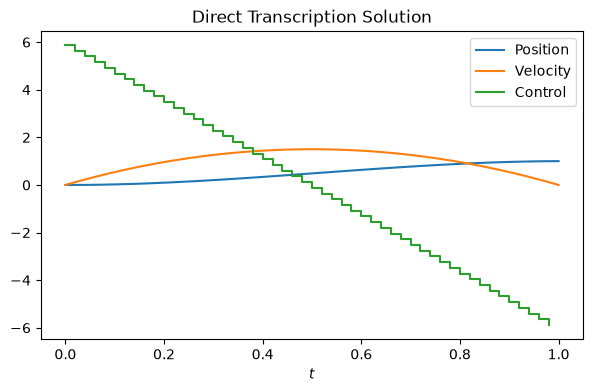

In [50]:
plt.figure(figsize=(7, 4))

plt.plot(
    time_states,
    position_star,
    label="Position",
)

plt.plot(
    time_states,
    velocity_star,
    label="Velocity",
)

plt.step(
    time_controls,
    controls_star,
    where="post",
    label="Control",
)

plt.xlabel("$t$")
plt.title("Direct Transcription Solution")
plt.legend()
plt.show()

## 6. Verify the Solution

A successful optimizer termination alone is not enough.

The solution should satisfy three checks:

1. The boundary conditions are satisfied.
2. The discretized dynamics constraints are satisfied.
3. The objective is minimized while maintaining feasibility.

For the optimized decision vector $z^\star$,

$$
c(z^\star) \approx 0
$$

indicates that the resulting state and control trajectories satisfy the
transcribed optimal control problem.

In [51]:
z_star = jnp.asarray(result.x)

states_star, controls_star = unpack_decision(z_star)

constraint_violation = equality_constraints(z_star)

print("Initial state:")
print(states_star[0])

print("\nFinal state:")
print(states_star[-1])

print("\nOptimal cost:")
print(objective_z(z_star))

print("\nMaximum constraint violation:")
print(jnp.max(jnp.abs(constraint_violation)))

Initial state:
[ 1.36762037e-18 -8.81164326e-18]

Final state:
[1. 0.]

Optimal cost:
6.002400966957637

Maximum constraint violation:
2.220446049250313e-16


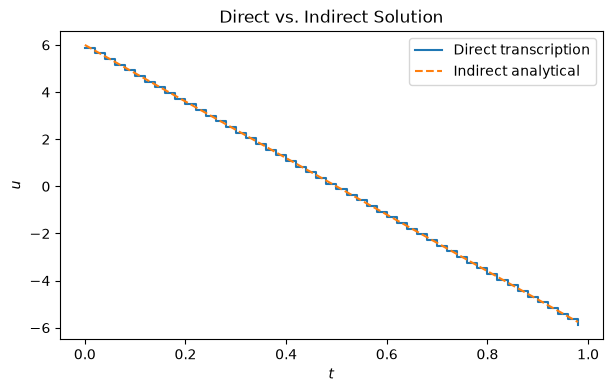

In [52]:
u_analytical = 6.0 - 12.0 * time_controls

plt.figure(figsize=(7, 4))

plt.step(
    time_controls,
    controls_star,
    where="post",
    label="Direct transcription",
)

plt.plot(
    time_controls,
    u_analytical,
    "--",
    label="Indirect analytical",
)

plt.xlabel("$t$")
plt.ylabel("$u$")
plt.title("Direct vs. Indirect Solution")
plt.legend()
plt.show()

### Takeaway

Direct transcription converted the continuous optimal control problem

$$
\min_{x(t),u(t)} J
\qquad
\text{subject to}
\qquad
\dot{x}=f(x,u)
$$

into the finite-dimensional constrained problem

$$
\min_z J(z)
\qquad
\text{subject to}
\qquad
c(z)=0.
$$

The decision vector contains the discretized state and control trajectories,

$$
z=[X,U].
$$

The differential dynamics become algebraic equality constraints,

$$
x_{k+1}-x_k-\Delta t f(x_k,u_k)=0.
$$

An NLP solver then searches for a low-cost, feasible trajectory.

Unlike the indirect method, we did not derive costate equations or solve a
two-point boundary-value problem.

# Case Study

## 1. Nonlinear 2D Car — Problem Formulation

### Requirement

A vehicle starts from a known position, heading, and speed.

The goal is to reach a desired terminal position and heading within a fixed
time horizon while producing a physically feasible and reasonably smooth
trajectory.

The vehicle should:

- reach the target pose,
- avoid unnecessary acceleration,
- avoid unnecessary steering,
- respect acceleration limits,
- respect steering-angle limits.

The problem will first be solved without obstacles so that the effects of the
vehicle dynamics, objective, and actuator constraints remain easy to interpret.

### State and Control

The vehicle state is

$$
x=
\begin{bmatrix}
p_x\\
p_y\\
\theta\\
v
\end{bmatrix},
$$

where

- $p_x,p_y$: planar position,
- $\theta$: heading angle,
- $v$: longitudinal speed.

The control is

$$
u=
\begin{bmatrix}
a\\
\delta
\end{bmatrix},
$$

where

- $a$: longitudinal acceleration,
- $\delta$: steering angle.

### Vehicle Dynamics

We use a kinematic bicycle model:

$$
\dot p_x=v\cos\theta,
$$

$$
\dot p_y=v\sin\theta,
$$

$$
\dot\theta=\frac{v}{L}\tan\delta,
$$

$$
\dot v=a.
$$

Therefore,

$$
\dot x=
f(x,u)=
\begin{bmatrix}
v\cos\theta\\
v\sin\theta\\
\dfrac{v}{L}\tan\delta\\
a
\end{bmatrix}.
$$

The parameter $L$ is the vehicle wheelbase and is a physical model parameter,
not an optimization variable.

In [54]:
from dataclasses import dataclass

@dataclass
class VehicleParams:
    wheelbase: float = 2.7

vehicle = VehicleParams()    

In [70]:
def car_dynamics(x, u, params):
    px, py, theta, v = x
    a, delta = u

    return jnp.array([
        v * jnp.cos(theta),
        v * jnp.sin(theta),
        v / params.wheelbase * jnp.tan(delta),
        a
    ])

### Cost Function Design

The requirement contains two different goals:

1. Reach the desired terminal state.
2. Avoid unnecessarily aggressive control.

We therefore use a terminal-state cost together with a running control-effort cost.

The total objective is

$$
J=
\phi(x_N)
+
\sum_{k=0}^{N-1}
\ell(x_k,u_k)\Delta t.
$$

For the first experiment,

$$
\phi(x_N)=
(x_N-x_{\text{target}})^T
Q_f
(x_N-x_{\text{target}})
$$

and

$$
\ell(x_k,u_k)=
u_k^T R u_k.
$$

The matrix $Q_f$ determines how strongly terminal-state errors are penalized,
while $R$ determines how strongly acceleration and steering effort are penalized.

In [71]:
@dataclass
class CostWeights:
    terminal_position: float = 100.0
    terminal_heading: float = 50.0
    terminal_speed: float = 20.0
    acceleration: float = 0.1
    steering: float = 0.5

weights = CostWeights()

In [72]:
def car_stage_cost(x,u, weights):
    a, delta = u

    return (
        weights.acceleration * a**2 + weights.steering * delta**2
    )

In [73]:
def car_terminal_cost(x, x_target, weights):
    position_error = x[:2] - x_target[:2]
    heading_error = x[2] - x_target[2]
    speed_error = x[3] - x_target[3]

    return (
        weights.terminal_position * position_error @ position_error
        + weights.terminal_heading * heading_error**2
        + weights.terminal_speed * speed_error**2
    )

In [87]:
def car_objective(states, controls, dt, x_target, weights):
    running_costs = jax.vmap(
        lambda x, u: car_stage_cost(x, u, weights)
    )(states[:-1], controls)

    terminal_cost = car_terminal_cost(
        states[-1],
        x_target,
        weights,
    )

    return jnp.sum(running_costs) * dt + terminal_cost

### Scenario and Hard Constraints

We now define a concrete maneuver.

The vehicle starts at

$$
x_0 =
\begin{bmatrix}
0\\
0\\
0\\
2
\end{bmatrix},
$$

corresponding to

- position: $(0,0)$ m,
- heading: $0$ rad,
- speed: $2$ m/s.

The desired terminal state is

$$
x_{\text{target}} =
\begin{bmatrix}
10\\
3\\
0\\
2
\end{bmatrix}.
$$

The vehicle therefore has to move forward while producing a lateral displacement
of $3$ m and finishing with approximately the original heading and speed.

We use a fixed horizon

$$
T = 5\text{ s}.
$$

Unlike terminal tracking errors, actuator limits represent physical restrictions
and are therefore imposed as **hard constraints**:

$$
a_{\min} \leq a_k \leq a_{\max},
$$

$$
\delta_{\min} \leq \delta_k \leq \delta_{\max}.
$$

This gives an important modeling distinction:

$$
\boxed{\text{Desired behavior} \rightarrow \text{cost}}
$$

while

$$
\boxed{\text{Physical limits} \rightarrow \text{hard constraints}}.
$$

In [88]:
T = 5.0
N = 50
dt = T / N

x_initial = jnp.array([
    0.0,   # px
    0.0,   # py
    0.0,   # heading
    2.0,   # speed
])

x_target = jnp.array([
    10.0,
    3.0,
    0.0,
    2.0,
])

In [89]:
A_MIN = -3.0
A_MAX =  2.0

DELTA_MIN = -0.5
DELTA_MAX =  0.5

### Discretize the nonlinear car dynamics

In [90]:
def car_discrete_dynamics(x, u, dt, params):
    return x + dt * car_dynamics(x, u, params)

### Dynamics Constraints

For every interval,

$$
x_{k+1}=
x_k+\Delta t\,f(x_k,u_k).
$$

Define the residual

$$
r_k=
x_{k+1}-
\left(
x_k+\Delta t\,f(x_k,u_k)
\right).
$$

A dynamically valid trajectory must satisfy

$$
\boxed{r_k=0}
$$

for every $k=0,\ldots,N-1$.

Since the car state has four components,

$$
r_k\in\mathbb{R}^4.
$$

Therefore $N$ transitions produce

$$
4N
$$

dynamics equality constraints.

In [91]:
def car_dynamics_residual(states, controls):
    predicted_next_states = jax.vmap(
        lambda x, u: car_discrete_dynamics(
            x,
            u,
            dt,
            vehicle,
        )
    )(states[:-1], controls)

    return states[1:] - predicted_next_states

### Initial Trajectory Guess

A nonlinear optimizer needs an initial decision vector

$$
z_0=[X_0,U_0].
$$

The initial guess does not need to be optimal, and it does not necessarily need
to satisfy all dynamics constraints.

However, a reasonable initial trajectory can make the nonlinear optimization
problem easier to solve.

For the state trajectory, we initialize the vehicle states by interpolating
between the initial and target states:

$$
x_k^{\text{guess}}=
x_{\text{initial}}
+
\frac{k}{N}
\left(
x_{\text{target}}-x_{\text{initial}}
\right).
$$

The controls are initially set to zero:

$$
u_k^{\text{guess}}=
\begin{bmatrix}
0\\
0
\end{bmatrix}.
$$

This provides the optimizer with a simple geometric guess for the desired
trajectory while leaving the dynamics constraints to determine whether that
trajectory is physically achievable.

In [92]:
alpha = jnp.linspace(
    0.0,
    1.0,
    N + 1,
)[:, None]

states_guess = (
    x_initial
    + alpha * (x_target - x_initial)
)

controls_guess = jnp.zeros((N, 2))

print("States:", states_guess.shape)
print("Controls:", controls_guess.shape)

States: (51, 4)
Controls: (50, 2)


In [93]:
initial_dynamics_residual = car_dynamics_residual(
    states_guess,
    controls_guess,
)

print(
    "Maximum initial dynamics violation:",
    jnp.max(jnp.abs(initial_dynamics_residual)),
)

Maximum initial dynamics violation: 0.0600000000000005


### Pack the decision variables

In [94]:
NX = 4
NU = 2


def pack_car_decision(states, controls):
    return jnp.concatenate([
        states.reshape(-1),
        controls.reshape(-1),
    ])


def unpack_car_decision(z):
    num_state_values = (N + 1) * NX

    states = z[:num_state_values].reshape(
        N + 1,
        NX,
    )

    controls = z[num_state_values:].reshape(
        N,
        NU,
    )

    return states, controls

In [95]:
z_guess = pack_car_decision(
    states_guess,
    controls_guess,
)

print(z_guess.shape)

(304,)


### Objective as J(z)

In [96]:
def car_objective_z(z):
    states, controls = unpack_car_decision(z)

    return car_objective(
        states,
        controls,
        dt,
        x_target,
        weights,
    )

In [97]:
print(
    "Initial objective:",
    car_objective_z(z_guess),
)

Initial objective: 0.0


### Equality Constraints

The initial state is a hard requirement,

$$
x_0=x_{\text{initial}}.
$$

The vehicle dynamics must also hold at every transition,

$$
x_{k+1}-
x_k-
\Delta t f(x_k,u_k)
=0.
$$

The target state is different: it is currently represented by a terminal cost
rather than an equality constraint.

Therefore,

$$
c(z)=
\begin{bmatrix}
x_0-x_{\text{initial}}\\
r_0\\
r_1\\
\vdots\\
r_{N-1}
\end{bmatrix}
=0.
$$

This distinguishes:

$$
\boxed{\text{must be satisfied} \rightarrow \text{constraint}}
$$

from

$$
\boxed{\text{should be achieved} \rightarrow \text{cost}}.
$$

In [98]:
def car_equality_constraints(z):
    states, controls = unpack_car_decision(z)

    initial_residual = (
        states[0] - x_initial
    )

    dynamics_residual = car_dynamics_residual(
        states,
        controls,
    ).reshape(-1)

    return jnp.concatenate([
        initial_residual,
        dynamics_residual,
    ])

In [99]:
c_guess = car_equality_constraints(z_guess)

print("Constraint shape:", c_guess.shape)

print(
    "Maximum constraint violation:",
    jnp.max(jnp.abs(c_guess)),
)

Constraint shape: (204,)
Maximum constraint violation: 0.0600000000000005


### Control Bounds

The vehicle actuators have physical limits.

For every time step,

$$
a_{\min}\leq a_k\leq a_{\max},
$$

and

$$
\delta_{\min}\leq\delta_k\leq\delta_{\max}.
$$

For this experiment,

$$
-3 \leq a_k \leq 2
$$

and

$$
-0.5 \leq \delta_k \leq 0.5.
$$

These are **hard constraints** rather than cost terms.

The optimizer is therefore not allowed to trade constraint violation for a lower
objective value.

### Complete Trajectory Optimization Problem

The decision variables are the complete state and control trajectories:

$$
X=\{x_0,\ldots,x_N\},
\qquad
U=\{u_0,\ldots,u_{N-1}\}.
$$

Equivalently,

$$
z=
\begin{bmatrix}
\operatorname{vec}(X)\\
\operatorname{vec}(U)
\end{bmatrix}.
$$

We solve

$$
\boxed{
\begin{aligned}
\min_{X,U}\quad
&
\phi(x_N)
+
\sum_{k=0}^{N-1}
\ell(x_k,u_k)\Delta t
\\[4pt]
\text{subject to}\quad
&
x_0=x_{\text{initial}},
\\
&
x_{k+1}=
x_k+\Delta t\,f(x_k,u_k),
\\
&
a_{\min}\leq a_k\leq a_{\max},
\\
&
\delta_{\min}\leq\delta_k\leq\delta_{\max}.
\end{aligned}
}
$$

The target state is currently a **soft requirement** represented by the terminal
cost

$$
\phi(x_N),
$$

while the initial state, vehicle dynamics, and actuator limits are hard
constraints.

### Construct the bounds

In [100]:
import numpy as np

num_state_values = (N + 1) * NX

lower_bounds = np.full(z_guess.shape, -np.inf)
upper_bounds = np.full(z_guess.shape,  np.inf)

In [101]:
control_lower = np.tile(
    np.array([A_MIN, DELTA_MIN]),
    N,
)

control_upper = np.tile(
    np.array([A_MAX, DELTA_MAX]),
    N,
)

In [102]:
lower_bounds[num_state_values:] = control_lower
upper_bounds[num_state_values:] = control_upper

In [103]:
bounds = list(zip(
    lower_bounds,
    upper_bounds,
))

### Prepare derivatives

In [104]:
car_objective_gradient = jax.grad(
    car_objective_z
)

car_constraint_jacobian = jax.jacfwd(
    car_equality_constraints
)

In [105]:
def car_objective_np(z):
    return float(
        car_objective_z(jnp.asarray(z))
    )


def car_objective_gradient_np(z):
    return np.asarray(
        car_objective_gradient(
            jnp.asarray(z)
        ),
        dtype=np.float64,
    )


def car_constraints_np(z):
    return np.asarray(
        car_equality_constraints(
            jnp.asarray(z)
        ),
        dtype=np.float64,
    )


def car_constraint_jacobian_np(z):
    return np.asarray(
        car_constraint_jacobian(
            jnp.asarray(z)
        ),
        dtype=np.float64,
    )

In [106]:
constraints = {
    "type": "eq",
    "fun": car_constraints_np,
    "jac": car_constraint_jacobian_np,
}

### Solve the NLP

In [107]:
from scipy.optimize import minimize

result = minimize(
    fun=car_objective_np,
    x0=np.asarray(z_guess),
    jac=car_objective_gradient_np,
    constraints=constraints,
    bounds=bounds,
    method="SLSQP",
    options={
        "maxiter": 1000,
        "ftol": 1e-8,
        "disp": True,
    },
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1590206935412727
            Iterations: 46
            Function evaluations: 50
            Gradient evaluations: 46


In [108]:
print("Success:", result.success)
print("Message:", result.message)
print("Objective:", result.fun)

print(
    "Maximum equality constraint violation:",
    np.max(
        np.abs(
            car_constraints_np(result.x)
        )
    ),
)

Success: True
Message: Optimization terminated successfully
Objective: 0.1590206935412727
Maximum equality constraint violation: 3.1305730230357653e-10


In [109]:
states_star, controls_star = unpack_car_decision(
    jnp.asarray(result.x)
)

px_star = states_star[:, 0]
py_star = states_star[:, 1]
theta_star = states_star[:, 2]
speed_star = states_star[:, 3]

acceleration_star = controls_star[:, 0]
steering_star = controls_star[:, 1]

In [110]:
print("Initial state:")
print(states_star[0])

print("\nFinal state:")
print(states_star[-1])

print("\nTarget state:")
print(x_target)

Initial state:
[7.63810488e-21 1.30394138e-20 1.59857489e-21 2.00000000e+00]

Final state:
[1.00001889e+01 2.99956710e+00 4.79351568e-03 2.00101581e+00]

Target state:
[10.  3.  0.  2.]


In [111]:
terminal_error = states_star[-1] - x_target

print("Terminal error:")
print(terminal_error)

Terminal error:
[ 0.00018894 -0.0004329   0.00479352  0.00101581]


### Plot the 2D path

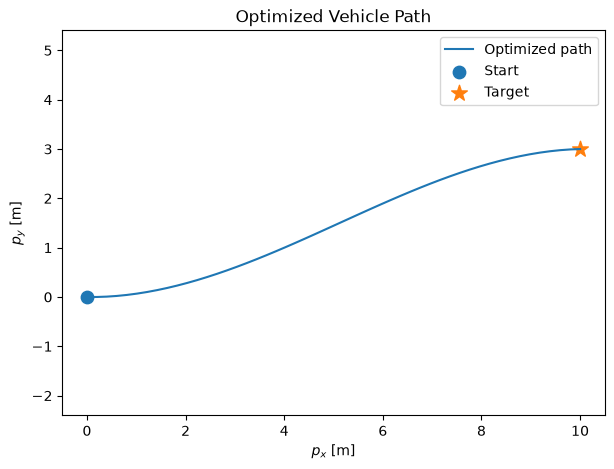

In [112]:
plt.figure(figsize=(7, 5))

plt.plot(
    px_star,
    py_star,
    label="Optimized path",
)

plt.scatter(
    x_initial[0],
    x_initial[1],
    marker="o",
    s=80,
    label="Start",
)

plt.scatter(
    x_target[0],
    x_target[1],
    marker="*",
    s=140,
    label="Target",
)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.title("Optimized Vehicle Path")
plt.axis("equal")
plt.legend()
plt.show()

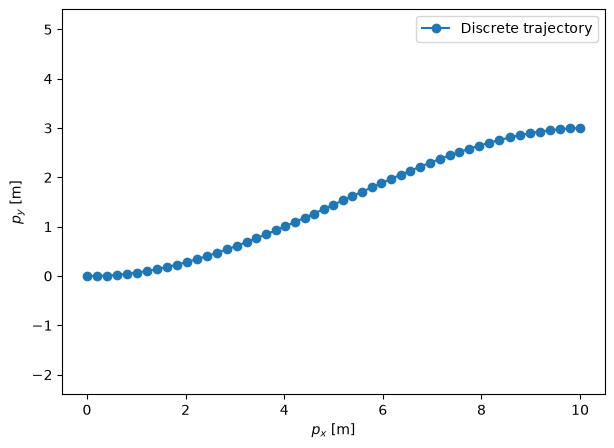

In [128]:
plt.figure(figsize=(7, 5))

plt.plot(
    px_star,
    py_star,
    marker="o",
    label="Discrete trajectory",
)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.axis("equal")
plt.legend()
plt.show()

### Plot heading and speed

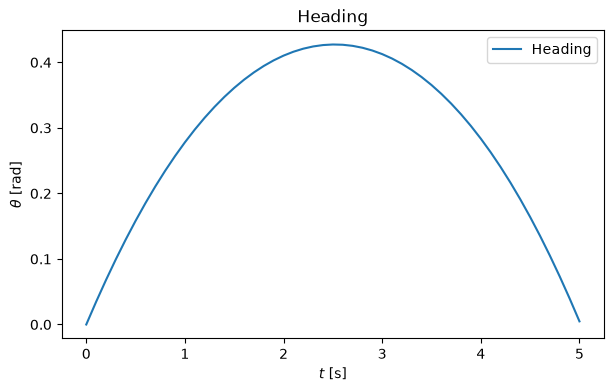

In [113]:
time_states = jnp.linspace(
    0.0,
    T,
    N + 1,
)

plt.figure(figsize=(7, 4))

plt.plot(
    time_states,
    theta_star,
    label="Heading",
)

plt.xlabel("$t$ [s]")
plt.ylabel("$\\theta$ [rad]")
plt.title("Heading")
plt.legend()
plt.show()

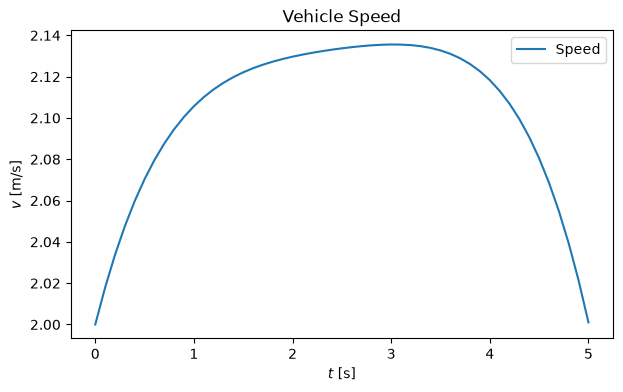

In [114]:
plt.figure(figsize=(7, 4))

plt.plot(
    time_states,
    speed_star,
    label="Speed",
)

plt.xlabel("$t$ [s]")
plt.ylabel("$v$ [m/s]")
plt.title("Vehicle Speed")
plt.legend()
plt.show()

### Plot the controls

In [115]:
time_controls = time_states[:-1]

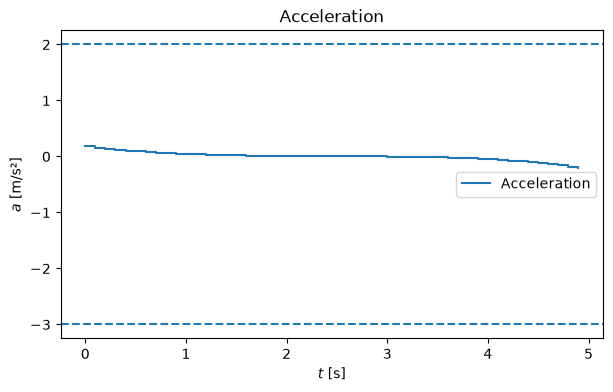

In [116]:
plt.figure(figsize=(7, 4))

plt.step(
    time_controls,
    acceleration_star,
    where="post",
    label="Acceleration",
)

plt.axhline(A_MIN, linestyle="--")
plt.axhline(A_MAX, linestyle="--")

plt.xlabel("$t$ [s]")
plt.ylabel("$a$ [m/s²]")
plt.title("Acceleration")
plt.legend()
plt.show()

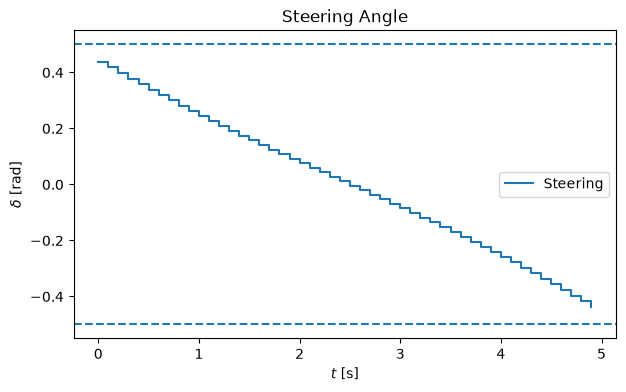

In [117]:
plt.figure(figsize=(7, 4))

plt.step(
    time_controls,
    steering_star,
    where="post",
    label="Steering",
)

plt.axhline(DELTA_MIN, linestyle="--")
plt.axhline(DELTA_MAX, linestyle="--")

plt.xlabel("$t$ [s]")
plt.ylabel("$\\delta$ [rad]")
plt.title("Steering Angle")
plt.legend()
plt.show()

In [118]:
terminal_error = states_star[-1] - x_target

print("Final state:")
print(states_star[-1])

print("\nTarget state:")
print(x_target)

print("\nTerminal error:")
print(terminal_error)

Final state:
[1.00001889e+01 2.99956710e+00 4.79351568e-03 2.00101581e+00]

Target state:
[10.  3.  0.  2.]

Terminal error:
[ 0.00018894 -0.0004329   0.00479352  0.00101581]


In [119]:
print(
    "Position error:",
    jnp.linalg.norm(
        states_star[-1, :2] - x_target[:2]
    ),
)

print(
    "Heading error:",
    states_star[-1, 2] - x_target[2],
)

print(
    "Speed error:",
    states_star[-1, 3] - x_target[3],
)

Position error: 0.0004723329912027647
Heading error: 0.004793515679281825
Speed error: 0.0010158070387014106


### First cost-weight experiment

In [120]:
terminal_position = 100.0

In [121]:
weights_strong_position = CostWeights(
    terminal_position=1000.0,
    terminal_heading=50.0,
    terminal_speed=20.0,
    acceleration=0.1,
    steering=0.5,
)

In [122]:
def car_objective_z_strong_position(z):
    states, controls = unpack_car_decision(z)

    return car_objective(
        states,
        controls,
        dt,
        x_target,
        weights_strong_position,
    )

In [123]:
car_objective_gradient_strong = jax.grad(
    car_objective_z_strong_position
)

In [124]:
def objective_strong_np(z):
    return float(
        car_objective_z_strong_position(
            jnp.asarray(z)
        )
    )


def gradient_strong_np(z):
    return np.asarray(
        car_objective_gradient_strong(
            jnp.asarray(z)
        ),
        dtype=np.float64,
    )

In [125]:
result_strong = minimize(
    fun=objective_strong_np,
    x0=result.x,
    jac=gradient_strong_np,
    constraints=constraints,
    bounds=bounds,
    method="SLSQP",
    options={
        "maxiter": 1000,
        "ftol": 1e-8,
        "disp": True,
    },
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1590408805514511
            Iterations: 5
            Function evaluations: 13
            Gradient evaluations: 5


In [126]:
states_strong, controls_strong = unpack_car_decision(
    jnp.asarray(result_strong.x)
)

In [127]:
error_original = jnp.linalg.norm(
    states_star[-1, :2] - x_target[:2]
)

error_strong = jnp.linalg.norm(
    states_strong[-1, :2] - x_target[:2]
)

print("Original terminal position error:", error_original)
print("Higher-weight terminal position error:", error_strong)

Original terminal position error: 0.0004723329912027647
Higher-weight terminal position error: 4.742385796045621e-05


## Sequential Convex Programming — Connection

The 2D car problem is nonlinear because the dynamics contain terms such as

$$
\cos\theta,
\qquad
\sin\theta,
\qquad
\tan\delta.
$$

Therefore, the transcribed optimization problem is generally nonconvex.

Sequential Convex Programming (SCP) addresses this by repeatedly solving
simpler local convex approximations.

Given a nominal trajectory

$$
x_k^{(i)},\qquad u_k^{(i)},
$$

the nonlinear dynamics are locally linearized:

$$
f(x,u)
\approx
f(\bar x,\bar u)
+
A(x-\bar x)
+
B(u-\bar u),
$$

where

$$
A=
\frac{\partial f}{\partial x},
\qquad
B=
\frac{\partial f}{\partial u}.
$$

The resulting convex subproblem is solved to obtain a new trajectory, which
becomes the nominal trajectory for the next iteration.

Conceptually,

$$
\boxed{
\text{nominal trajectory}
\rightarrow
\text{linearize}
\rightarrow
\text{solve convex subproblem}
\rightarrow
\text{update trajectory}
\rightarrow
\text{repeat}
}
$$

This follows the same local-approximation idea that will appear again in later
algorithms such as iLQR.

In [129]:
A = jax.jacfwd(
    car_dynamics,
    argnums=0,
)

B = jax.jacfwd(
    car_dynamics,
    argnums=1,
)

x_nom = states_star[10]
u_nom = controls_star[10]

A_nom = A(x_nom, u_nom, vehicle)
B_nom = B(x_nom, u_nom, vehicle)

print("A shape:", A_nom.shape)
print("B shape:", B_nom.shape)

A shape: (4, 4)
B shape: (4, 2)


## Takeaway

Direct methods solve optimal control problems by converting them into
finite-dimensional constrained optimization problems.

The main workflow was

$$
\boxed{
\text{Requirement}
\rightarrow
\text{Model}
\rightarrow
\text{Cost}
\rightarrow
\text{Constraints}
\rightarrow
\text{Discretization}
\rightarrow
\text{NLP}
\rightarrow
\text{Optimal trajectory}
}
$$

### Double integrator

The simple example exposed the transcription process clearly:

$$
\dot x=f(x,u)
$$

became

$$
x_{k+1}-
x_k-
\Delta t f(x_k,u_k)=
0.
$$

The complete state and control trajectories became optimization variables.

### Nonlinear 2D car

The same framework was then applied to

$$
x=
[p_x,p_y,\theta,v],
\qquad
u=
[a,\delta].
$$

The problem included:

- nonlinear vehicle dynamics,
- terminal tracking costs,
- control-effort costs,
- hard actuator limits,
- dynamics constraints,
- a finite prediction horizon.

The experiment also showed that problem design matters:

$$
\text{cost weights}
\rightarrow
\text{behavioral trade-offs},
$$

$$
\text{hard constraints}
\rightarrow
\text{requirements that cannot be violated},
$$

and

$$
N,\Delta t
\rightarrow
\text{accuracy/computational trade-off}.
$$

Direct methods are optimization methods, not learning methods. Changing the
initial state, target, constraints, or design parameters generally requires
solving a new optimization problem.

For nonlinear systems, methods such as SCP exploit local approximations and
problem structure rather than treating the trajectory optimization problem as
an arbitrary dense optimization problem.